<a href="https://colab.research.google.com/github/davidrpugh/introduction-to-deep-learning/blob/master/notebooks/03c-faster-optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn import model_selection, preprocessing, pipeline
import torch
from torch import nn, optim, utils

# Preliminaries

## Define some utility functions

In [2]:
def clip_gradients_(
    clip_grad_strategy,
    model_fn,
    clip_value=None,
    error_if_nonfinite=False,
    max_norm=None,
    norm_type=2.0):
    if clip_grad_strategy == "value" and clip_value is not None:
        nn.utils.clip_grad_value_(
            model_fn.parameters(),
            clip_value
        )
    elif clip_grad_strategy == "norm" and max_norm is not None:
        nn.utils.clip_grad_norm_(
            model_fn.parameters(),
            max_norm,
            norm_type,
            error_if_nonfinite
        )
    elif clip_grad_strategy is None:
        pass
    else:
        raise NotImplementedError()


def compute_average_loss(dataloader, loss_fn, model_fn):
    total_loss = torch.zeros(1, 1)
    for features, targets in dataloader:
        predictions = model_fn(features)
        total_loss += loss_fn(predictions, targets)
    average_loss = total_loss / len(dataloader)
    return average_loss


def initialize_linear_layer(
    in_features,
    out_features,
    init_strategy_=nn.init.kaiming_uniform_):
    linear_layer = nn.Linear(in_features, out_features)
    init_strategy_(linear_layer.weight)
    return linear_layer


def make_mlp_classifier(
    input_size,
    hidden_sizes=None,
    output_size=2,
    activation_fn=None,
    init_strategy_=nn.init.kaiming_uniform_,
    batch_normalization=False):
    modules = []
    hidden_sizes = [] if hidden_sizes is None else hidden_sizes
    for hidden_size in hidden_sizes:
        hidden_layer = initialize_linear_layer(
            input_size,
            hidden_size,
            init_strategy_,
        )
        modules.append(hidden_layer)
        if batch_normalization:
            modules.append(nn.BatchNorm1d(hidden_size))
        if activation_fn is not None:
            modules.append(activation_fn)
        input_size=hidden_size
    output_layer = initialize_linear_layer(
            input_size,
            output_size,
            init_strategy_,
    )
    modules.append(output_layer)
    modules.append(nn.LogSoftmax(dim=1))
    model_fn = nn.Sequential(*modules)
    return model_fn, nn.NLLLoss()


## Define our training loop

In [3]:
def fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    clip_grad_strategy=None,
    clip_value=None,
    error_if_nonfinite=False,
    log_epochs=1,
    max_epochs=1,
    max_norm=None,
    norm_type=2.0):

    history = {
        "epoch": [],
        "average_train_loss": [],
        "average_val_loss": []
    }

    for epoch in range(max_epochs):
        total_train_loss = torch.zeros(1, 1)
        model_fn = model_fn.train()
        for features, targets in train_dataloader:

            # forward pass
            predictions = model_fn(features)
            loss = loss_fn(predictions, targets)
            total_train_loss += loss

            # backward pass
            loss.backward()
            clip_gradients_(
                clip_grad_strategy,
                model_fn,
                clip_value,
                error_if_nonfinite,
                max_norm,
                norm_type
            )
            optimizer.step()
            optimizer.zero_grad()

        average_train_loss = total_train_loss / len(train_dataloader)
        history["epoch"].append(epoch)
        history["average_train_loss"].append(average_train_loss.item())

        # validation after every training epoch
        model_fn = model_fn.eval()
        with torch.inference_mode():
            average_val_loss = compute_average_loss(
                val_dataloader,
                loss_fn,
                model_fn
            )
        history["average_val_loss"].append(average_val_loss.item())


        if epoch % log_epochs == 0:
            message = f"Epoch {epoch}, Average train Loss {average_train_loss.item():.4f}, Average val Loss {average_val_loss.item():.4f}"
            print(message)

    history_df = (pd.DataFrame.from_dict(history)
                              .set_index("epoch"))
    return history_df


## Load the Data

In [4]:
INPUT_SIZE = 784
OUTPUT_SIZE = 10

_train_data = pd.read_csv(
    "./sample_data/mnist_train_small.csv",
    header=None,
    names=["label"] + [f"p{i}" for i in range(INPUT_SIZE)],
)
train_data, val_data = model_selection.train_test_split(
    _train_data,
    test_size=0.1,
    stratify=_train_data.loc[:, "label"]
)

test_data = pd.read_csv(
    "./sample_data/mnist_test.csv",
    header=None,
    names=["label"] + [f"p{i}" for i in range(INPUT_SIZE)],
)


In [5]:
features_preprocessor = pipeline.make_pipeline(
    preprocessing.MinMaxScaler(),
    preprocessing.FunctionTransformer(lambda arr: arr.astype(np.float32)),
    preprocessing.FunctionTransformer(lambda arr: torch.from_numpy(arr))
)

target_preprocessor = pipeline.make_pipeline(
    preprocessing.FunctionTransformer(lambda df: df.to_numpy()),
    preprocessing.FunctionTransformer(lambda arr: torch.from_numpy(arr))
)


In [6]:
BATCH_SIZE = 64
NUM_WORKERS = 2

# create the training dataset and dataloader
train_features_tensor = features_preprocessor.fit_transform(
    train_data.drop("label", axis=1)
)

train_target_tensor = target_preprocessor.fit_transform(
    train_data.loc[:, "label"]
)

train_dataset = utils.data.TensorDataset(
    train_features_tensor,
    train_target_tensor
)

train_dataloader = utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# create the validation dataset and dataloader
val_features_tensor = features_preprocessor.transform(
    val_data.drop("label", axis=1)
)

val_target_tensor = target_preprocessor.transform(
    val_data.loc[:, "label"]
)

val_dataset = utils.data.TensorDataset(
    val_features_tensor,
    val_target_tensor
)

val_dataloader = utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# create the test dataset and dataloader
test_features_tensor = features_preprocessor.transform(
    test_data.drop("label", axis=1)
)

test_target_tensor = target_preprocessor.transform(
    test_data.loc[:, "label"]
)

test_dataset = utils.data.TensorDataset(
    test_features_tensor,
    test_target_tensor
)

test_dataloader = utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)


# Faster Optimizers


## SGD

In [ ]:
optim.SGD?

In [7]:
HIDDEN_SIZE = 100
LEARNING_RATE = 1e-2
MAX_EPOCHS = 20

model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.SGD(model_fn.parameters(), lr=LEARNING_RATE)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    max_epochs=MAX_EPOCHS
)

Epoch 0, Average train Loss 0.8089, Average val Loss 0.5064
Epoch 1, Average train Loss 0.4025, Average val Loss 0.4250
Epoch 2, Average train Loss 0.3427, Average val Loss 0.3931
Epoch 3, Average train Loss 0.3123, Average val Loss 0.3738
Epoch 4, Average train Loss 0.2920, Average val Loss 0.3603
Epoch 5, Average train Loss 0.2765, Average val Loss 0.3495
Epoch 6, Average train Loss 0.2638, Average val Loss 0.3405
Epoch 7, Average train Loss 0.2527, Average val Loss 0.3326
Epoch 8, Average train Loss 0.2429, Average val Loss 0.3257
Epoch 9, Average train Loss 0.2338, Average val Loss 0.3194
Epoch 10, Average train Loss 0.2255, Average val Loss 0.3135
Epoch 11, Average train Loss 0.2178, Average val Loss 0.3080
Epoch 12, Average train Loss 0.2105, Average val Loss 0.3029
Epoch 13, Average train Loss 0.2036, Average val Loss 0.2979
Epoch 14, Average train Loss 0.1970, Average val Loss 0.2932
Epoch 15, Average train Loss 0.1907, Average val Loss 0.2888
Epoch 16, Average train Loss 0.184

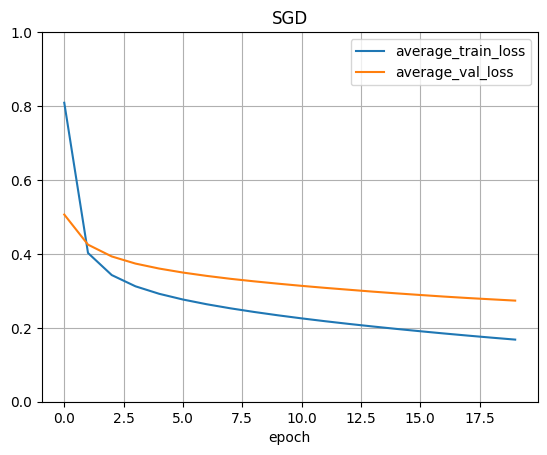

In [9]:
_ = history.plot(title="SGD", grid=True, ylim=(0, 1))

## Momentum

In [10]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.SGD(
    model_fn.parameters(),
    lr=LEARNING_RATE,
    momentum=0.9,
    dampening=0.0,
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    max_epochs=MAX_EPOCHS
)

Epoch 0, Average train Loss 0.4523, Average val Loss 0.3513
Epoch 1, Average train Loss 0.2534, Average val Loss 0.2815
Epoch 2, Average train Loss 0.1954, Average val Loss 0.2388
Epoch 3, Average train Loss 0.1563, Average val Loss 0.2111
Epoch 4, Average train Loss 0.1278, Average val Loss 0.1971
Epoch 5, Average train Loss 0.1061, Average val Loss 0.1880
Epoch 6, Average train Loss 0.0888, Average val Loss 0.1817
Epoch 7, Average train Loss 0.0748, Average val Loss 0.1802
Epoch 8, Average train Loss 0.0633, Average val Loss 0.1790
Epoch 9, Average train Loss 0.0537, Average val Loss 0.1819
Epoch 10, Average train Loss 0.0460, Average val Loss 0.1832
Epoch 11, Average train Loss 0.0391, Average val Loss 0.1867
Epoch 12, Average train Loss 0.0335, Average val Loss 0.1898
Epoch 13, Average train Loss 0.0288, Average val Loss 0.1969
Epoch 14, Average train Loss 0.0252, Average val Loss 0.2080
Epoch 15, Average train Loss 0.0217, Average val Loss 0.2155
Epoch 16, Average train Loss 0.017

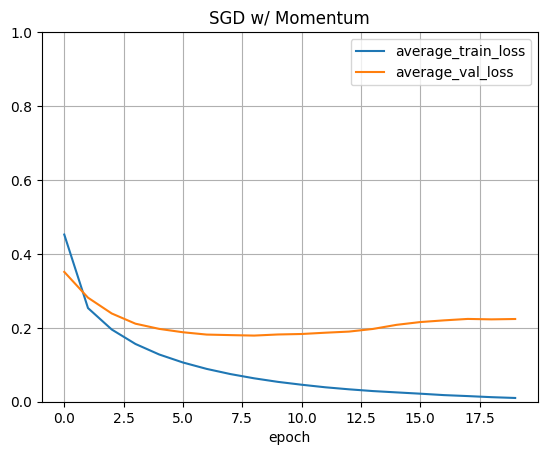

In [11]:
_ = history.plot(title="SGD w/ Momentum", grid=True, ylim=(0, 1))

## Momentum with Nesterov Accelerated Gradient

In [12]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.SGD(
    model_fn.parameters(),
    lr=LEARNING_RATE,
    momentum=0.9,
    dampening=0,
    nesterov=True,
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    max_epochs=MAX_EPOCHS
)

Epoch 0, Average train Loss 0.4383, Average val Loss 0.3440
Epoch 1, Average train Loss 0.2543, Average val Loss 0.2871
Epoch 2, Average train Loss 0.1952, Average val Loss 0.2496
Epoch 3, Average train Loss 0.1566, Average val Loss 0.2268
Epoch 4, Average train Loss 0.1276, Average val Loss 0.2128
Epoch 5, Average train Loss 0.1050, Average val Loss 0.2056
Epoch 6, Average train Loss 0.0876, Average val Loss 0.2020
Epoch 7, Average train Loss 0.0735, Average val Loss 0.1973
Epoch 8, Average train Loss 0.0615, Average val Loss 0.1926
Epoch 9, Average train Loss 0.0511, Average val Loss 0.1895
Epoch 10, Average train Loss 0.0425, Average val Loss 0.1870
Epoch 11, Average train Loss 0.0348, Average val Loss 0.1882
Epoch 12, Average train Loss 0.0284, Average val Loss 0.1966
Epoch 13, Average train Loss 0.0236, Average val Loss 0.2062
Epoch 14, Average train Loss 0.0194, Average val Loss 0.2104
Epoch 15, Average train Loss 0.0158, Average val Loss 0.2131
Epoch 16, Average train Loss 0.012

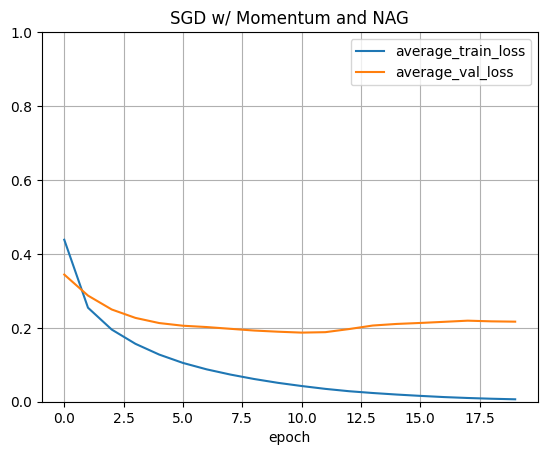

In [13]:
_ = history.plot(title="SGD w/ Momentum and NAG", grid=True, ylim=(0, 1))

### Exercise

Re-train your model for different values of momentum both with and without NAG. What is the best combination of these hyperparameters that you can find?

## AdaGrad

In [ ]:
optim.Adagrad?

In [14]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.Adagrad(
    model_fn.parameters(),
    lr=LEARNING_RATE,
    lr_decay=0.0,
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    max_epochs=MAX_EPOCHS
)

Epoch 0, Average train Loss 0.4035, Average val Loss 0.2942
Epoch 1, Average train Loss 0.2239, Average val Loss 0.2617
Epoch 2, Average train Loss 0.1824, Average val Loss 0.2400
Epoch 3, Average train Loss 0.1560, Average val Loss 0.2269
Epoch 4, Average train Loss 0.1373, Average val Loss 0.2168
Epoch 5, Average train Loss 0.1229, Average val Loss 0.2091
Epoch 6, Average train Loss 0.1112, Average val Loss 0.2031
Epoch 7, Average train Loss 0.1014, Average val Loss 0.1983
Epoch 8, Average train Loss 0.0930, Average val Loss 0.1941
Epoch 9, Average train Loss 0.0856, Average val Loss 0.1909
Epoch 10, Average train Loss 0.0791, Average val Loss 0.1882
Epoch 11, Average train Loss 0.0732, Average val Loss 0.1860
Epoch 12, Average train Loss 0.0680, Average val Loss 0.1841
Epoch 13, Average train Loss 0.0632, Average val Loss 0.1826
Epoch 14, Average train Loss 0.0588, Average val Loss 0.1813
Epoch 15, Average train Loss 0.0547, Average val Loss 0.1806
Epoch 16, Average train Loss 0.051

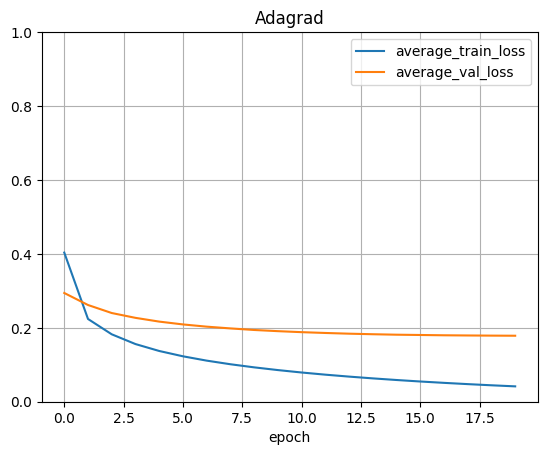

In [15]:
_ = history.plot(title="Adagrad", grid=True, ylim=(0, 1))

## Adam

In [ ]:
optim.Adam?

In [16]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.Adam(
    model_fn.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    amsgrad=False,
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    max_epochs=MAX_EPOCHS
)

Epoch 0, Average train Loss 0.5151, Average val Loss 0.2962
Epoch 1, Average train Loss 0.2545, Average val Loss 0.2873
Epoch 2, Average train Loss 0.2361, Average val Loss 0.4532
Epoch 3, Average train Loss 0.2201, Average val Loss 0.3554
Epoch 4, Average train Loss 0.2348, Average val Loss 0.4511
Epoch 5, Average train Loss 0.2112, Average val Loss 0.4365
Epoch 6, Average train Loss 0.1960, Average val Loss 0.5224
Epoch 7, Average train Loss 0.2057, Average val Loss 0.3615
Epoch 8, Average train Loss 0.1771, Average val Loss 0.5081
Epoch 9, Average train Loss 0.1676, Average val Loss 0.3846
Epoch 10, Average train Loss 0.2073, Average val Loss 0.5429
Epoch 11, Average train Loss 0.1743, Average val Loss 0.3595
Epoch 12, Average train Loss 0.1501, Average val Loss 0.4857
Epoch 13, Average train Loss 0.1718, Average val Loss 0.6574
Epoch 14, Average train Loss 0.3019, Average val Loss 0.8380
Epoch 15, Average train Loss 0.1954, Average val Loss 0.4106
Epoch 16, Average train Loss 0.123

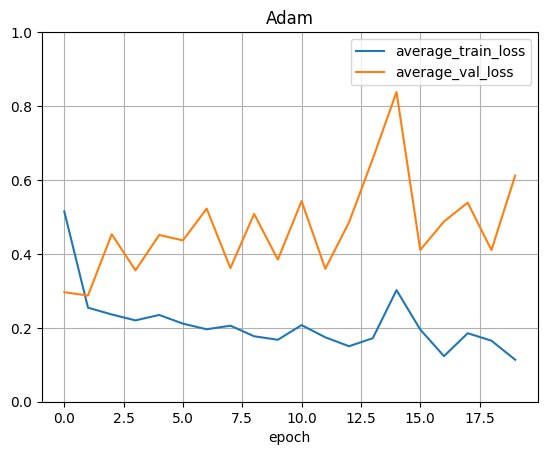

In [17]:
_ = history.plot(title="Adam", grid=True, ylim=(0, 1))

## Adam variants: Adamax, Nadam, AdamW

In [ ]:
optim.Adamax?

In [ ]:
optim.NAdam?

In [ ]:
optim.AdamW?

In [18]:
model_fn, loss_fn = make_mlp_classifier(
    input_size=INPUT_SIZE,
    hidden_sizes=[HIDDEN_SIZE, HIDDEN_SIZE, HIDDEN_SIZE],
    output_size=OUTPUT_SIZE,
    activation_fn=nn.SELU(),
    init_strategy_=nn.init.xavier_normal_
)

optimizer = optim.AdamW(
    model_fn.parameters(),
    lr=LEARNING_RATE,
    amsgrad=False,
    betas=(0.9, 0.999),
    weight_decay=1e-2,
)

history = fit(
    loss_fn,
    model_fn,
    optimizer,
    train_dataloader,
    val_dataloader,
    max_epochs=MAX_EPOCHS
)


Epoch 0, Average train Loss 0.4760, Average val Loss 0.3526
Epoch 1, Average train Loss 0.2931, Average val Loss 0.2894
Epoch 2, Average train Loss 0.2302, Average val Loss 0.2818
Epoch 3, Average train Loss 0.1926, Average val Loss 0.3289
Epoch 4, Average train Loss 0.2563, Average val Loss 0.2533
Epoch 5, Average train Loss 0.2057, Average val Loss 0.4216
Epoch 6, Average train Loss 0.1920, Average val Loss 0.4329
Epoch 7, Average train Loss 0.2410, Average val Loss 0.2738
Epoch 8, Average train Loss 0.1604, Average val Loss 0.4642
Epoch 9, Average train Loss 0.1547, Average val Loss 0.4405
Epoch 10, Average train Loss 0.1395, Average val Loss 0.3722
Epoch 11, Average train Loss 0.1528, Average val Loss 0.4034
Epoch 12, Average train Loss 0.2384, Average val Loss 0.7254
Epoch 13, Average train Loss 0.2134, Average val Loss 0.3151
Epoch 14, Average train Loss 0.1260, Average val Loss 0.4247
Epoch 15, Average train Loss 0.1769, Average val Loss 0.3413
Epoch 16, Average train Loss 0.170

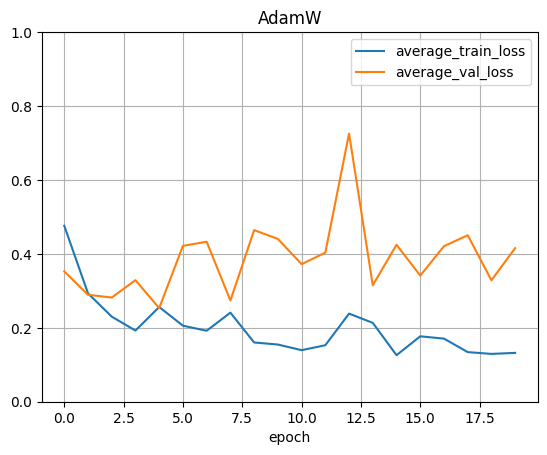

In [19]:
_ = history.plot(title="AdamW", grid=True, ylim=(0, 1))

## Exercise:

Create a MLP with three hidden layers, each with 100 neurons per layer, and train it for 10 epochs using the following optimizers.

1. Adam
2. Adamax
3. NAdam
4. AdamW

Plot the training and validation loss curves. Compare and contrast.